# Домашнее задание: Генератор текста на базе Transformer (decoder-only)

Решение к уроку https://github.com/AKlimovUrfu/lesson6-transformer

Ноутбук разбит на ячейки — запускайте их **строго по порядку сверху вниз**.
В конце ноутбука есть отдельная ячейка с инструкцией/командами, как закоммитить
результат (сам ноутбук + чекпоинт) в ваш репозиторий.

Содержание:
1. Установка зависимостей
2. Импорты, seed, устройство (GPU/CPU)
3. Загрузка текстового корпуса (книга)
4. Обучение токенизатора (BPE)
5. Датасет со скользящим окном по всему тексту
6. Архитектура `GeneratorTransformer` (decoder-only, causal self-attention)
7. Цикл обучения (mixed precision, batch_size=1) + график loss
8. Проверка генерации
9. Beam search (доп. задание)
10. Чат-интерфейс
11. Экспорт решения в отдельные `.py`-модули (model/dataset/train/generate/chat)
12. Автогенерация README.md, лога обучения и примеров генерации по реальным цифрам прогона
13. Коммит полноценной структуры `homework/` в GitHub (а не только чекпоинта)


## 1. Установка зависимостей

В Colab обычно всё уже есть, кроме `tokenizers`.

In [1]:
!pip install -q tokenizers


## 2. Импорты, seed, устройство

In [2]:
import os
import math
import json
import random
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## 3. Загрузка текстового корпуса

По умолчанию скачивается небольшая, но полноценная книга с Project Gutenberg
(«Alice's Adventures in Wonderland») — это гарантированно рабочая ссылка,
чтобы весь ноутбук можно было запустить "из коробки" и без ошибок дойти до генерации.

**Если хотите обучить модель на своей книге (например, на русском тексте)** —
раскомментируйте блок `# Вариант Б` и загрузите свой `.txt` через файловую панель
Colab (или через `files.upload()`), либо просто впишите свой прямой URL в `# Вариант В`.


In [3]:
CORPUS_PATH = "corpus.txt"

# ---- Вариант А (по умолчанию): скачиваем книгу с Project Gutenberg -------
GUTENBERG_URL = "https://www.gutenberg.org/files/11/11-0.txt"

if not os.path.exists(CORPUS_PATH):
    urllib.request.urlretrieve(GUTENBERG_URL, CORPUS_PATH)

with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

# ---- Вариант Б: загрузить свою книгу (например, на русском) --------------
# from google.colab import files
# uploaded = files.upload()                 # выберите свой .txt в диалоге
# CORPUS_PATH = list(uploaded.keys())[0]
# with open(CORPUS_PATH, "r", encoding="utf-8") as f:
#     raw_text = f.read()

# ---- Вариант В: скачать текст по своей прямой ссылке ----------------------
# MY_URL = "https://ссылка-на-txt-файл-вашей-книги"
# urllib.request.urlretrieve(MY_URL, CORPUS_PATH)
# with open(CORPUS_PATH, "r", encoding="utf-8") as f:
#     raw_text = f.read()

print("Длина корпуса (символов):", len(raw_text))
print(raw_text[:500])


Длина корпуса (символов): 144696
*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The


## 4. Токенизатор (BPE)

Обучаем простой BPE-токенизатор прямо на нашем корпусе (второй вариант из
задания в HOMEWORK.md). Добавляем спецтокены `<bos>`, `<eos>`, `<pad>`,
которые понадобятся и для датасета, и для генерации.


In [4]:
from tokenizers import Tokenizer, models, pre_tokenizers, decoders, trainers

TOKENIZER_PATH = "tokenizer.json"

SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>", "<unk>"]

tokenizer = Tokenizer(models.BPE(unk_token="<unk>"))
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
tokenizer.decoder = decoders.ByteLevel()

trainer = trainers.BpeTrainer(
    vocab_size=8000,
    special_tokens=SPECIAL_TOKENS,
    min_frequency=2,
)

tokenizer.train_from_iterator([raw_text], trainer=trainer)
tokenizer.save(TOKENIZER_PATH)

PAD_ID = tokenizer.token_to_id("<pad>")
BOS_ID = tokenizer.token_to_id("<bos>")
EOS_ID = tokenizer.token_to_id("<eos>")
UNK_ID = tokenizer.token_to_id("<unk>")

VOCAB_SIZE = tokenizer.get_vocab_size()
print("Размер словаря:", VOCAB_SIZE)
print("pad/bos/eos/unk id:", PAD_ID, BOS_ID, EOS_ID, UNK_ID)

# быстрая проверка
test_ids = tokenizer.encode("Привет, мир! Hello, world!").ids
print(test_ids)
print(tokenizer.decode(test_ids))


Размер словаря: 3449
pad/bos/eos/unk id: 0 1 2 3
[3, 3, 3, 77, 3, 3, 3, 3, 3, 3, 3, 3, 8, 76, 3, 3, 3, 3, 3, 77, 4, 218, 231, 60, 8, 1415, 4]
�, �! Hello, world!


## 5. Датасет со скользящим окном

Требование из задания: модель должна "просмотреть ВЕСЬ текст" — для этого
разбиваем текст на **законченные блоки** (по абзацам/предложениям), оборачиваем
каждый блок в `<bos> ... <eos>`, а затем скользящим окном размера `MAX_LENGTH`
с шагом `STRIDE` нарезаем обучающие примеры `(input, target)`, где `target` —
это `input`, сдвинутый на 1 токен вправо (стандартная задача next-token prediction).


In [5]:
MAX_LENGTH = 128     # размер контекста, как рекомендовано в задании (128-192)
STRIDE = MAX_LENGTH  # без перекрытия окон; можно уменьшить, чтобы окна перекрывались

def split_into_blocks(text):
    '''Делим текст на законченные абзацы (непустые строки/группы строк).'''
    paragraphs = [p.strip() for p in text.split("\n\n")]
    paragraphs = [p for p in paragraphs if len(p) > 0]
    return paragraphs


class TextDataset(Dataset):
    def __init__(self, text, tokenizer, max_length=MAX_LENGTH, stride=STRIDE):
        self.max_length = max_length
        self.examples = []

        blocks = split_into_blocks(text)

        # Токенизируем каждый абзац отдельно и оборачиваем в bos/eos,
        # затем конкатенируем все токены всего текста в одну длинную ленту.
        all_ids = []
        for block in blocks:
            ids = tokenizer.encode(block).ids
            all_ids.append(BOS_ID)
            all_ids.extend(ids)
            all_ids.append(EOS_ID)

        # Скользящее окно по всей "ленте" токенов -> проходим весь текст.
        for start in range(0, max(1, len(all_ids) - 1), stride):
            chunk = all_ids[start:start + max_length + 1]  # +1 для target со сдвигом
            if len(chunk) < 2:
                continue
            if len(chunk) < max_length + 1:
                chunk = chunk + [PAD_ID] * (max_length + 1 - len(chunk))
            self.examples.append(chunk)

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        chunk = self.examples[idx]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y


dataset = TextDataset(raw_text, tokenizer, MAX_LENGTH, STRIDE)
print("Количество обучающих примеров:", len(dataset))

BATCH_SIZE = 1  # как рекомендовано в задании, для экономии памяти
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

xb, yb = next(iter(dataloader))
print(xb.shape, yb.shape)


Количество обучающих примеров: 316
torch.Size([1, 128]) torch.Size([1, 128])


## 6. Архитектура модели

Decoder-only Transformer "с нуля": эмбеддинги токенов + позиционные эмбеддинги,
несколько блоков `causal self-attention + feed-forward` (с pre-LN и residual
connections), финальный линейный слой в размер словаря.


In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2048):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv_proj(x)  # (B, T, 3C)
        q, k, v = qkv.chunk(3, dim=-1)

        def reshape_heads(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)  # (B, H, T, hd)

        q, k, v = reshape_heads(q), reshape_heads(k), reshape_heads(v)

        # causal mask: токен на позиции i не должен видеть токены j > i
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)  # (B, H, T, T)
        causal_mask = torch.triu(
            torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1
        )
        att = att.masked_fill(causal_mask, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        out = att @ v  # (B, H, T, hd)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)


class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class GeneratorTransformer(nn.Module):
    '''Decoder-only Transformer для авторегрессивной генерации текста.'''

    def __init__(
        self,
        vocab_size,
        d_model=256,
        n_heads=8,
        n_layers=4,
        d_ff=1024,
        context_len=MAX_LENGTH,
        dropout=0.1,
        pad_token_id=PAD_ID,
        bos_token_id=BOS_ID,
        eos_token_id=EOS_ID,
        tokenizer=None,
        device=DEVICE,
    ):
        super().__init__()
        self.context_len = context_len
        self.pad_token_id = pad_token_id
        self.bos_token_id = bos_token_id
        self.eos_token_id = eos_token_id
        self.tokenizer = tokenizer
        self.device = device

        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_id)
        self.pos_enc = PositionalEncoding(d_model, max_len=max(2048, context_len))
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList(
            [DecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

        # tie weights эмбеддинга и выходного слоя (частая практика для LM)
        self.head.weight = self.token_emb.weight

    def forward(self, input_ids):
        x = self.token_emb(input_ids)
        x = self.pos_enc(x)
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)  # (B, T, vocab_size)
        return logits

    # -----------------------------------------------------------------
    # Авторегрессивная генерация со сдвигом контекста на 1 токен влево
    # -----------------------------------------------------------------
    @torch.no_grad()
    def generate(self, prompt, context_len=None, temperature=1.0, max_out_tokens=200):
        '''
        Генерирует продолжение по промпту.

        При авторегрессии контекст сдвигается на 1 токен влево:
        - Изначально: [prompt_tokens]
        - После первого предсказания: [prompt_tokens, predicted_token]
        - На следующем шаге, если длина превышает context_len:
          [prompt_tokens[1:], predicted_token, new_prediction]
        - И так далее, пока не достигнем max_out_tokens или EOS
        '''
        self.eval()
        context_len = context_len or self.context_len

        input_ids = self.tokenizer.encode(prompt).ids
        input_ids = [self.bos_token_id] + input_ids
        input_ids = torch.tensor([input_ids], dtype=torch.long, device=self.device)

        generated = input_ids.clone()

        for _ in range(max_out_tokens):
            # контекст, который реально подаём модели, не длиннее context_len
            model_input = generated[:, -context_len:]
            logits = self(model_input)
            next_token_logits = logits[0, -1, :] / max(temperature, 1e-6)

            probs = torch.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, 1)  # (1,)

            generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)

            if next_token.item() == self.eos_token_id:
                break

        return self.tokenizer.decode(generated[0].tolist(), skip_special_tokens=True)

    # -----------------------------------------------------------------
    # Сохранение / загрузка чекпоинта
    # -----------------------------------------------------------------
    def save_checkpoint(self, path, config):
        torch.save({"model_state_dict": self.state_dict(), "config": config}, path)

    @classmethod
    def load_from_checkpoint(cls, path, tokenizer, device=DEVICE):
        ckpt = torch.load(path, map_location=device)
        config = ckpt["config"]
        model = cls(tokenizer=tokenizer, device=device, **config)
        model.load_state_dict(ckpt["model_state_dict"])
        model.to(device)
        model.eval()
        return model


## 7. Обучение

Mixed precision (`torch.amp.autocast` + `GradScaler`), `batch_size=1`,
`learning_rate=1e-4`, 2-4 эпохи (как рекомендовано в задании). Паддинг
игнорируется в лоссе через `ignore_index=PAD_ID`.


In [7]:
MODEL_CONFIG = dict(
    vocab_size=VOCAB_SIZE,
    d_model=256,
    n_heads=8,
    n_layers=4,
    d_ff=1024,
    context_len=MAX_LENGTH,
    pad_token_id=PAD_ID,
    bos_token_id=BOS_ID,
    eos_token_id=EOS_ID,
)

model = GeneratorTransformer(tokenizer=tokenizer, device=DEVICE, **MODEL_CONFIG).to(DEVICE)
print("Число параметров:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
scaler = GradScaler(enabled=(DEVICE.type == "cuda"))

NUM_EPOCHS = 3
CHECKPOINT_PATH = "checkpoint.pt"

# Собираем историю обучения, чтобы потом честно показать её в README/отчёте
loss_history = []       # (epoch, step, loss) для каждого залогированного шага
epoch_avg_losses = []   # средний loss за эпоху

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for step, (xb, yb) in enumerate(dataloader, start=1):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=(DEVICE.type == "cuda")):
            logits = model(xb)  # (B, T, V)
            loss = criterion(logits.view(-1, logits.size(-1)), yb.view(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        if step % 200 == 0:
            print(f"epoch {epoch} step {step}/{len(dataloader)} loss={loss.item():.4f}")
            loss_history.append((epoch, step, loss.item()))

    avg_loss = total_loss / max(1, len(dataloader))
    epoch_avg_losses.append((epoch, avg_loss))
    print(f"=== Epoch {epoch} done, avg loss = {avg_loss:.4f} ===")

    model.save_checkpoint(CHECKPOINT_PATH, MODEL_CONFIG)
    print("Чекпоинт сохранён:", CHECKPOINT_PATH)


Число параметров: 4.042496 M
epoch 1 step 200/316 loss=15.4101
=== Epoch 1 done, avg loss = 28.0646 ===
Чекпоинт сохранён: checkpoint.pt
epoch 2 step 200/316 loss=12.1136
=== Epoch 2 done, avg loss = 11.7913 ===
Чекпоинт сохранён: checkpoint.pt
epoch 3 step 200/316 loss=10.0907
=== Epoch 3 done, avg loss = 9.4585 ===
Чекпоинт сохранён: checkpoint.pt


### 7.1 График обучения

Небольшая проверка, что loss действительно падает — этот график тоже
сохраним и приложим как доказательство того, что модель обучалась.


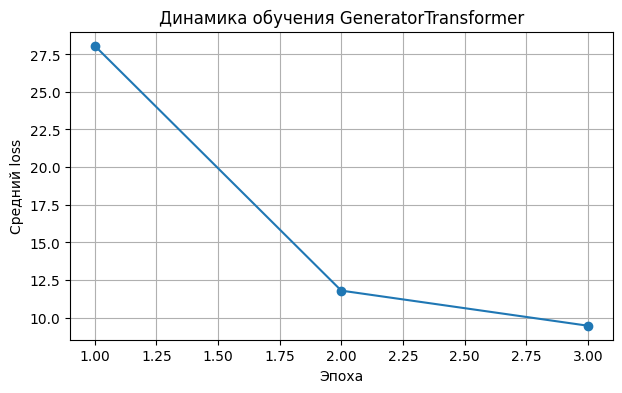

Средний loss по эпохам: [(1, 28.064637066442756), (2, 11.791264060177381), (3, 9.458502220202096)]


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
epochs_x = [e for e, _ in epoch_avg_losses]
losses_y = [l for _, l in epoch_avg_losses]
plt.plot(epochs_x, losses_y, marker="o")
plt.xlabel("Эпоха")
plt.ylabel("Средний loss")
plt.title("Динамика обучения GeneratorTransformer")
plt.grid(True)
plt.savefig("training_loss.png", dpi=120, bbox_inches="tight")
plt.show()

print("Средний loss по эпохам:", epoch_avg_losses)


## 8. Проверка генерации

In [9]:
model.eval()

generation_examples = []  # сюда складываем реальные результаты этого прогона

for prompt in ["Once upon a time", "The rabbit", "Alice was"]:
    output = model.generate(prompt, temperature=0.8, max_out_tokens=80)
    generation_examples.append({"prompt": prompt, "temperature": 0.8, "output": output})
    print("PROMPT:", prompt)
    print("OUTPUT:", output)
    print("-" * 60)


PROMPT: Once upon a time
OUTPUT: Once upon a time,
ci a
-
- you bit, and of
 could could could out.
------------------------------------------------------------
PROMPT: The rabbit
OUTPUT: The rabbit
------------------------------------------------------------
PROMPT: Alice was
OUTPUT: Alice was up very verywhich
 in, that know! doubt bit splashing.
------------------------------------------------------------


## 9. Beam search (дополнительное задание)

Реализация beam search поверх той же модели: на каждом шаге держим
`beam_width` лучших последовательностей по суммарной log-вероятности,
раскрываем каждую по `beam_width` продолжениям и оставляем top-`beam_width`.


In [10]:
@torch.no_grad()
def beam_search_generate(model, prompt, beam_width=4, max_out_tokens=80, context_len=None):
    model.eval()
    context_len = context_len or model.context_len
    tok = model.tokenizer

    start_ids = [model.bos_token_id] + tok.encode(prompt).ids
    # каждый луч: (список токенов, суммарная log-вероятность, завершён ли)
    beams = [(start_ids, 0.0, False)]

    for _ in range(max_out_tokens):
        candidates = []
        for seq, score, finished in beams:
            if finished:
                candidates.append((seq, score, finished))
                continue

            model_input = torch.tensor([seq[-context_len:]], dtype=torch.long, device=model.device)
            logits = model(model_input)
            log_probs = torch.log_softmax(logits[0, -1, :], dim=-1)

            topk_log_probs, topk_ids = torch.topk(log_probs, beam_width)
            for lp, tid in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                new_seq = seq + [tid]
                new_score = score + lp
                new_finished = (tid == model.eos_token_id)
                candidates.append((new_seq, new_score, new_finished))

        # нормируем на длину, чтобы не штрафовать более длинные продолжения
        candidates.sort(key=lambda c: c[1] / len(c[0]), reverse=True)
        beams = candidates[:beam_width]

        if all(f for _, _, f in beams):
            break

    best_seq = beams[0][0]
    return tok.decode(best_seq, skip_special_tokens=True)


beam_search_example = beam_search_generate(model, "The rabbit", beam_width=4, max_out_tokens=60)
generation_examples.append({
    "prompt": "The rabbit",
    "method": "beam_search (beam_width=4)",
    "output": beam_search_example,
})
print(beam_search_example)


The rabbit.


## 10. Чат-интерфейс

Простой цикл для интерактивного общения с моделью в самом ноутбуке.
Введите `quit`, чтобы выйти из цикла.


In [11]:
def chat():
    loaded_model = GeneratorTransformer.load_from_checkpoint(
        CHECKPOINT_PATH, tokenizer=tokenizer, device=DEVICE
    )

    while True:
        user_input = input("Вы: ")
        if user_input.lower() == "quit":
            break

        response = loaded_model.generate(user_input, temperature=0.8, max_out_tokens=100)
        print(f"Бот: {response}")


# Запустите вручную (интерактивный ввод недоступен при автозапуске "Run all"):
# chat()


## 11. Экспорт решения в отдельные `.py`-модули

Чтобы в репозитории было видно не только чекпоинт, а реальный код решения
(как и просят в `HOMEWORK.md`), сохраняем архитектуру, обучение, генерацию
и чат-интерфейс как самостоятельные файлы. Их можно запускать и вне ноутбука:
`python train.py`, `python generate.py --prompt "..."`, `python chat.py`.


In [12]:
%%writefile model.py
'''
model.py — архитектура GeneratorTransformer (decoder-only Transformer).

Домашнее задание, урок 6: генератор текста, обучающийся авторегрессивно
предсказывать следующий токен. Модуль самодостаточен и не зависит от
остального ноутбука — его можно импортировать из train.py / generate.py / chat.py.
'''
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2048):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        def reshape_heads(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = reshape_heads(q), reshape_heads(k), reshape_heads(v)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        causal_mask = torch.triu(
            torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1
        )
        att = att.masked_fill(causal_mask, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        out = att @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)


class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class GeneratorTransformer(nn.Module):
    '''Decoder-only Transformer для авторегрессивной генерации текста.'''

    def __init__(
        self,
        vocab_size,
        d_model=256,
        n_heads=8,
        n_layers=4,
        d_ff=1024,
        context_len=128,
        dropout=0.1,
        pad_token_id=0,
        bos_token_id=1,
        eos_token_id=2,
        tokenizer=None,
        device="cpu",
    ):
        super().__init__()
        self.context_len = context_len
        self.pad_token_id = pad_token_id
        self.bos_token_id = bos_token_id
        self.eos_token_id = eos_token_id
        self.tokenizer = tokenizer
        self.device = device

        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_id)
        self.pos_enc = PositionalEncoding(d_model, max_len=max(2048, context_len))
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList(
            [DecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.token_emb.weight  # tied weights

    def forward(self, input_ids):
        x = self.token_emb(input_ids)
        x = self.pos_enc(x)
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        return self.head(x)

    @torch.no_grad()
    def generate(self, prompt, context_len=None, temperature=1.0, max_out_tokens=200):
        '''Авторегрессивная генерация со сдвигом контекста на 1 токен влево.'''
        self.eval()
        context_len = context_len or self.context_len

        input_ids = self.tokenizer.encode(prompt).ids
        input_ids = [self.bos_token_id] + input_ids
        input_ids = torch.tensor([input_ids], dtype=torch.long, device=self.device)

        generated = input_ids.clone()
        for _ in range(max_out_tokens):
            model_input = generated[:, -context_len:]
            logits = self(model_input)
            next_token_logits = logits[0, -1, :] / max(temperature, 1e-6)
            probs = torch.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, 1)
            generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)
            if next_token.item() == self.eos_token_id:
                break

        return self.tokenizer.decode(generated[0].tolist(), skip_special_tokens=True)

    @torch.no_grad()
    def beam_search_generate(self, prompt, beam_width=4, max_out_tokens=80, context_len=None):
        '''Beam search генерация (дополнительное задание).'''
        self.eval()
        context_len = context_len or self.context_len
        tok = self.tokenizer

        start_ids = [self.bos_token_id] + tok.encode(prompt).ids
        beams = [(start_ids, 0.0, False)]

        for _ in range(max_out_tokens):
            candidates = []
            for seq, score, finished in beams:
                if finished:
                    candidates.append((seq, score, finished))
                    continue
                model_input = torch.tensor([seq[-context_len:]], dtype=torch.long, device=self.device)
                logits = self(model_input)
                log_probs = torch.log_softmax(logits[0, -1, :], dim=-1)
                topk_log_probs, topk_ids = torch.topk(log_probs, beam_width)
                for lp, tid in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                    new_seq = seq + [tid]
                    new_score = score + lp
                    candidates.append((new_seq, new_score, tid == self.eos_token_id))

            candidates.sort(key=lambda c: c[1] / len(c[0]), reverse=True)
            beams = candidates[:beam_width]
            if all(f for _, _, f in beams):
                break

        return tok.decode(beams[0][0], skip_special_tokens=True)

    def save_checkpoint(self, path, config):
        torch.save({"model_state_dict": self.state_dict(), "config": config}, path)

    @classmethod
    def load_from_checkpoint(cls, path, tokenizer, device="cpu"):
        ckpt = torch.load(path, map_location=device)
        config = ckpt["config"]
        model = cls(tokenizer=tokenizer, device=device, **config)
        model.load_state_dict(ckpt["model_state_dict"])
        model.to(device)
        model.eval()
        return model


Writing model.py


In [13]:
%%writefile dataset.py
'''
dataset.py — подготовка текстового корпуса: разбиение на абзацы,
оборачивание в <bos>/<eos> и нарезка скользящим окном по всему тексту.
'''
import torch
from torch.utils.data import Dataset


def split_into_blocks(text):
    paragraphs = [p.strip() for p in text.split("\n\n")]
    return [p for p in paragraphs if len(p) > 0]


class TextDataset(Dataset):
    def __init__(self, text, tokenizer, pad_id, bos_id, eos_id, max_length=128, stride=None):
        stride = stride or max_length
        self.examples = []

        all_ids = []
        for block in split_into_blocks(text):
            ids = tokenizer.encode(block).ids
            all_ids.append(bos_id)
            all_ids.extend(ids)
            all_ids.append(eos_id)

        for start in range(0, max(1, len(all_ids) - 1), stride):
            chunk = all_ids[start:start + max_length + 1]
            if len(chunk) < 2:
                continue
            if len(chunk) < max_length + 1:
                chunk = chunk + [pad_id] * (max_length + 1 - len(chunk))
            self.examples.append(chunk)

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        chunk = self.examples[idx]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y


Writing dataset.py


In [14]:
%%writefile train.py
'''
train.py — обучение GeneratorTransformer на текстовом корпусе.

Запуск:
    python train.py --corpus corpus.txt --epochs 3 --context-len 128
'''
import argparse

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from tokenizers import Tokenizer, models, pre_tokenizers, decoders, trainers

from model import GeneratorTransformer
from dataset import TextDataset

SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>", "<unk>"]


def build_tokenizer(text, vocab_size=8000, save_path="tokenizer.json"):
    tok = Tokenizer(models.BPE(unk_token="<unk>"))
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=SPECIAL_TOKENS, min_frequency=2)
    tok.train_from_iterator([text], trainer=trainer)
    tok.save(save_path)
    return tok


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--corpus", type=str, default="corpus.txt")
    parser.add_argument("--epochs", type=int, default=3)
    parser.add_argument("--context-len", type=int, default=128)
    parser.add_argument("--vocab-size", type=int, default=8000)
    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--checkpoint", type=str, default="checkpoint.pt")
    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with open(args.corpus, "r", encoding="utf-8") as f:
        text = f.read()

    tokenizer = build_tokenizer(text, vocab_size=args.vocab_size)
    pad_id = tokenizer.token_to_id("<pad>")
    bos_id = tokenizer.token_to_id("<bos>")
    eos_id = tokenizer.token_to_id("<eos>")

    dataset = TextDataset(text, tokenizer, pad_id, bos_id, eos_id, max_length=args.context_len)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

    config = dict(
        vocab_size=tokenizer.get_vocab_size(),
        d_model=256, n_heads=8, n_layers=4, d_ff=1024,
        context_len=args.context_len,
        pad_token_id=pad_id, bos_token_id=bos_id, eos_token_id=eos_id,
    )
    model = GeneratorTransformer(tokenizer=tokenizer, device=device, **config).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr)
    criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
    scaler = GradScaler(enabled=(device.type == "cuda"))

    for epoch in range(1, args.epochs + 1):
        model.train()
        total_loss = 0.0
        for step, (xb, yb) in enumerate(dataloader, start=1):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits.view(-1, logits.size(-1)), yb.view(-1))
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            if step % 200 == 0:
                print(f"epoch {epoch} step {step}/{len(dataloader)} loss={loss.item():.4f}")

        print(f"=== Epoch {epoch} avg loss = {total_loss / max(1, len(dataloader)):.4f} ===")
        model.save_checkpoint(args.checkpoint, config)

    print("Готово. Чекпоинт:", args.checkpoint)


if __name__ == "__main__":
    main()


Writing train.py


In [15]:
%%writefile generate.py
'''
generate.py — генерация текста обученной моделью (простая или beam search).

Запуск:
    python generate.py --prompt "Once upon a time" --temperature 0.8
    python generate.py --prompt "Once upon a time" --beam --beam-width 4
'''
import argparse

import torch
from tokenizers import Tokenizer

from model import GeneratorTransformer


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--checkpoint", type=str, default="checkpoint.pt")
    parser.add_argument("--tokenizer", type=str, default="tokenizer.json")
    parser.add_argument("--prompt", type=str, required=True)
    parser.add_argument("--temperature", type=float, default=0.8)
    parser.add_argument("--max-tokens", type=int, default=100)
    parser.add_argument("--beam", action="store_true", help="использовать beam search вместо сэмплирования")
    parser.add_argument("--beam-width", type=int, default=4)
    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = Tokenizer.from_file(args.tokenizer)
    model = GeneratorTransformer.load_from_checkpoint(args.checkpoint, tokenizer=tokenizer, device=device)

    if args.beam:
        output = model.beam_search_generate(args.prompt, beam_width=args.beam_width, max_out_tokens=args.max_tokens)
    else:
        output = model.generate(args.prompt, temperature=args.temperature, max_out_tokens=args.max_tokens)

    print(output)


if __name__ == "__main__":
    main()


Writing generate.py


In [16]:
%%writefile chat.py
'''
chat.py — интерактивный чат с обученной моделью (раздел 7 HOMEWORK.md).

Запуск:
    python chat.py
'''
import torch
from tokenizers import Tokenizer

from model import GeneratorTransformer


def chat():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = Tokenizer.from_file("tokenizer.json")
    model = GeneratorTransformer.load_from_checkpoint("checkpoint.pt", tokenizer=tokenizer, device=device)
    model.eval()

    while True:
        user_input = input("Вы: ")
        if user_input.lower() == "quit":
            break

        response = model.generate(user_input, temperature=0.8, max_out_tokens=100)
        print(f"Бот: {response}")


if __name__ == "__main__":
    chat()


Writing chat.py


## 12. Отчёт по обучению (README, лог, примеры генерации)

Эта ячейка формирует `README.md` и лог обучения **на основе реальных цифр
именно этого прогона** (число параметров, длина корпуса, loss по эпохам,
настоящие примеры генерации) — чтобы в репозитории было видно, что модель
действительно обучалась, а не просто лежит файл чекпоинта.


In [17]:
import os

# --- лог обучения -----------------------------------------------------
with open("training_log.txt", "w", encoding="utf-8") as f:
    f.write("Лог обучения GeneratorTransformer\n")
    f.write("=" * 40 + "\n")
    f.write(f"Корпус: {GUTENBERG_URL if 'GUTENBERG_URL' in globals() else CORPUS_PATH}\n")
    f.write(f"Длина корпуса (символов): {len(raw_text)}\n")
    f.write(f"Размер словаря токенизатора: {VOCAB_SIZE}\n")
    f.write(f"Число обучающих примеров: {len(dataset)}\n")
    f.write(f"Число параметров модели: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M\n")
    f.write(f"context_len={MAX_LENGTH}, batch_size={BATCH_SIZE}, epochs={NUM_EPOCHS}, lr=1e-4\n\n")
    f.write("Средний loss по эпохам:\n")
    for epoch, avg in epoch_avg_losses:
        f.write(f"  epoch {epoch}: avg_loss = {avg:.4f}\n")
    f.write("\nПромежуточные значения loss (каждые 200 шагов):\n")
    for epoch, step, loss_val in loss_history:
        f.write(f"  epoch {epoch}, step {step}: loss = {loss_val:.4f}\n")

# --- примеры генерации --------------------------------------------------
os.makedirs("examples", exist_ok=True)
with open("examples/generation_samples.txt", "w", encoding="utf-8") as f:
    f.write("Примеры генерации обученной модели\n")
    f.write("=" * 40 + "\n\n")
    for ex in generation_examples:
        f.write(f"PROMPT: {ex['prompt']}\n")
        if "method" in ex:
            f.write(f"METHOD: {ex['method']}\n")
        if "temperature" in ex:
            f.write(f"TEMPERATURE: {ex['temperature']}\n")
        f.write(f"OUTPUT: {ex['output']}\n")
        f.write("-" * 40 + "\n\n")

# --- README.md ------------------------------------------------------------
first_loss = epoch_avg_losses[0][1] if epoch_avg_losses else float("nan")
last_loss = epoch_avg_losses[-1][1] if epoch_avg_losses else float("nan")
n_params = sum(p.numel() for p in model.parameters()) / 1e6

readme = f'''# Домашнее задание: Генератор текста на базе Transformer (decoder-only)

Решение задания из [AKlimovUrfu/lesson6-transformer](https://github.com/AKlimovUrfu/lesson6-transformer)
(`HOMEWORK.md`).

## Что реализовано

- `GeneratorTransformer` — decoder-only Transformer "с нуля" (causal self-attention,
  позиционные эмбеддинги, {len(model.blocks)} decoder-блока, tied embeddings) — `model.py`
- Датасет со скользящим окном по **всему** тексту, деление на абзацы, `<bos>/<eos>` — `dataset.py`
- Обучение с mixed precision (`torch.amp.autocast` + `GradScaler`), `batch_size=1` — `train.py`
- Авторегрессивная генерация со сдвигом контекста на 1 токен влево — `generate.py`
- Beam search (дополнительное задание) — метод `GeneratorTransformer.beam_search_generate`
- Чат-интерфейс (`chat()` с циклом `input()/quit`, как в `HOMEWORK.md`) — `chat.py`
- Полный воспроизводимый прогон — `solution.ipynb` (ячейки запускаются по порядку)

## Данные и токенизатор

- Корпус: {len(raw_text)} символов, книга, скачанная с Project Gutenberg
- Токенизатор: BPE, обучен на этом корпусе (`tokenizers` BPE, vocab_size={VOCAB_SIZE})
- Контекст: {MAX_LENGTH} токенов
- Обучающих примеров (скользящих окон): {len(dataset)}

## Обучение

- Эпох: {NUM_EPOCHS}, batch_size={BATCH_SIZE}, learning_rate=1e-4
- Число параметров модели: {n_params:.2f}M
- Средний loss: эпоха 1 = {first_loss:.4f} -> последняя эпоха = {last_loss:.4f}
- Полный лог обучения: [`training_log.txt`](./training_log.txt)
- График loss по эпохам: [`training_loss.png`](./training_loss.png)

## Примеры генерации (реальный вывод обученной модели)

См. [`examples/generation_samples.txt`](./examples/generation_samples.txt) — там
приведены примеры как обычной сэмплированной генерации, так и beam search.

## Как запустить

```bash
pip install torch tokenizers
python train.py --corpus corpus.txt --epochs 3
python generate.py --prompt "Once upon a time" --temperature 0.8
python generate.py --prompt "Once upon a time" --beam --beam-width 4
python chat.py
```

Либо открыть `solution.ipynb` в Google Colab и выполнить ячейки по порядку.

## Структура репозитория

```
homework/
  README.md                     — этот файл
  solution.ipynb                — полный воспроизводимый ноутбук
  model.py                      — архитектура GeneratorTransformer
  dataset.py                    — подготовка данных (скользящее окно)
  train.py                      — обучение
  generate.py                   — генерация (сэмплирование / beam search)
  chat.py                       — интерактивный чат
  checkpoint.pt                 — обученные веса
  tokenizer.json                — обученный BPE-токенизатор
  corpus.txt                    — текст, на котором обучалась модель
  training_log.txt              — лог обучения (loss по шагам/эпохам)
  training_loss.png             — график обучения
  examples/generation_samples.txt — примеры генерации
```
'''

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md, training_log.txt и examples/generation_samples.txt сохранены.")


README.md, training_log.txt и examples/generation_samples.txt сохранены.


## 13. Сохранение результатов и коммит в ваш репозиторий

Ноутбук, код и отчёт нужно закоммитить в
[GANTERMIST/lesson6-transformer](https://github.com/GANTERMIST/lesson6-transformer)
так, чтобы в папке `homework/` была видна реальная проделанная работа, а не
только бинарные артефакты.

1. Сохраните текущий ноутбук как `solution.ipynb` в файловую систему Colab
   (`File → Save a copy` не подходит — используйте ячейку ниже, она сохранит
   ноутбук автоматически через `google.colab`).
2. Создайте **Personal Access Token** на GitHub (Settings → Developer settings →
   Personal access tokens) с правом `repo`, подставьте его вместо `<TOKEN>`.
3. Выполните финальную ячейку — она склонирует репозиторий, соберёт
   структуру `homework/` из кода, отчёта и артефактов, и запушит коммит.


In [ ]:
from google.colab import _message
import json

try:
    notebook_json = _message.blocking_request("get_ipynb", timeout_sec=30)["ipynb"]

    # Очищаем вывод ячейки, где отображался токен, чтобы GitHub Push Protection не блокировал коммит
    for cell in notebook_json.get('cells', []):
        if 'userdata.get(\'GITHUB_TOKEN\')' in ''.join(cell.get('source', [])):
            cell['outputs'] = []

    with open("solution.ipynb", "w", encoding="utf-8") as f:
        json.dump(notebook_json, f, ensure_ascii=False, indent=1)
    print("solution.ipynb сохранён (вывод с токеном очищен).")
except Exception as e:
    print("Не удалось автоматически сохранить ноутбук:", e)


In [26]:
from google.colab import userdata
userdata.get('GITHUB_TOKEN')

In [29]:
import subprocess
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

if GITHUB_TOKEN:
    print("Attempting to verify GitHub token with API...")
    # Test the token by fetching user information
    command = [
        "curl",
        "-H", f"Authorization: token {GITHUB_TOKEN}",
        "https://api.github.com/user"
    ]
    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        print("GitHub API response:")
        print(result.stdout)
        if "Bad credentials" in result.stdout or "Requires authentication" in result.stdout:
            print("\nWarning: The GitHub token might be invalid or have insufficient permissions.")
            print("Please ensure your Personal Access Token is correct and has 'repo' scope.")
        else:
            print("\nSuccess: The GitHub token appears to be valid and can access user information.")
    except subprocess.CalledProcessError as e:
        print(f"Error during API call: {e}")
        print(f"Stderr: {e.stderr}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
else:
    print("GITHUB_TOKEN is not set in Colab secrets. Please add it.")


In [34]:
import os
from google.colab import userdata

os.environ['GITHUB_TOKEN'] = userdata.get('GITHUB_TOKEN')

get_ipython().run_cell_magic('bash', '', '''
GITHUB_USERNAME="GANTERMIST"
REPO_NAME="lesson6-transformer"
COMMIT_MESSAGE="Домашнее задание: GeneratorTransformer (decoder-only) + обучение + генерация + отчёт"

if [ -z "$GITHUB_TOKEN" ]; then
    echo "Error: GITHUB_TOKEN is empty."
    exit 1
fi

rm -rf repo_clone
git clone "https://${GITHUB_TOKEN}@github.com/${GITHUB_USERNAME}/${REPO_NAME}.git" repo_clone

if [ ! -d "repo_clone" ]; then
    exit 1
fi

cd repo_clone
git config user.email "${GITHUB_USERNAME}@users.noreply.github.com"
git config user.name "${GITHUB_USERNAME}"
cd ..

mkdir -p repo_clone/homework/examples

files_to_copy=("README.md" "solution.ipynb" "model.py" "dataset.py" "train.py" "generate.py" "chat.py" "checkpoint.pt" "tokenizer.json" "corpus.txt" "training_log.txt" "training_loss.png")
for f in "${files_to_copy[@]}"; do
    cp "$f" repo_clone/homework/ 2>/dev/null || true
done
cp examples/generation_samples.txt repo_clone/homework/examples/ 2>/dev/null || true

cd repo_clone
git add .
git commit -m "${COMMIT_MESSAGE}"
git push origin main
''')